# Random Fourier Features — From Bochner's Theorem to Bayesian Spectral Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/random_fourier_features.ipynb)

Random Fourier Features (RFF) approximate a shift-invariant kernel by an explicit, finite-dimensional feature map sampled from the kernel's spectral density. They are the bridge between *kernel methods* (which scale cubically) and *neural network feature maps* (which are linear in the dataset size), and they recover Sparse Spectrum GP regression as a special case.

This notebook is the spectral counterpart of the [SIREN notebook](siren_inr.ipynb). Where SIREN attacks high-frequency targets with a learned sinusoidal MLP, RFF attacks them with a *fixed* sinusoidal basis sampled from a kernel's spectral measure. Four concrete uses of `pyrox.nn.RBFFourierFeatures`, `pyrox.nn.MaternFourierFeatures`, `pyrox.nn.LaplaceFourierFeatures`, `pyrox.nn.OrthogonalRandomFeatures`, and `pyrox.nn.VariationalFourierFeatures`:

1. **Bochner kernel approximation** — visualise the Monte Carlo Gram matrix converging to the exact RBF kernel as $M$ grows; verify the $1/\sqrt{M}$ rate.
2. **Variance reduction with Orthogonal RFF** — a Haar-orthogonal frequency matrix lowers Frobenius error at matched $M$ without changing the mean.
3. **Variational RFF — learning the spectrum** — replace the fixed prior $p(\omega)$ with a learned posterior $q_\phi(\omega)$ and watch the frequencies migrate toward the target's spectral support.
4. **Bayesian RFF + ensemble-of-MAP** — wrap `RBFFourierFeatures` in a `RandomKitchenSinks`-style head, run `pyrox.inference.ensemble_map`, and read off the predictive uncertainty as the band visibly opens across a held-out gap.

## Background — the math behind Random Fourier Features

### Bochner's theorem

A continuous, shift-invariant, real-valued positive-definite kernel $k(x, y) = k(x - y)$ on $\mathbb{R}^d$ is the Fourier transform of a finite non-negative *spectral measure* $\mu$:

$$k(x - y) = \int_{\mathbb{R}^d} e^{i\,\omega^\top (x - y)}\, d\mu(\omega).$$

Because $k$ is real, $\mu$ is symmetric ($\mu(\mathrm{d}\omega) = \mu(-\mathrm{d}\omega)$), so the imaginary part of the integral vanishes and we may write

$$k(x - y) = \mathbb{E}_{\omega \sim p(\omega)}\!\left[\cos\bigl(\omega^\top(x - y)\bigr)\right],$$

where $p(\omega) = \mu(\mathrm{d}\omega)/k(0)$ is the normalised *spectral density*. Bochner's theorem turns the abstract claim "the kernel is positive-definite" into the very concrete claim "the kernel is the characteristic function of a probability distribution on frequencies".

### Monte Carlo feature map (Rahimi & Recht, NeurIPS 2007)

Draw $\omega_1, \dots, \omega_M \stackrel{\text{iid}}{\sim} p(\omega)$ from the spectral density. Define the *paired* random Fourier feature map

$$\phi(x) = \sqrt{\tfrac{1}{M}}\,\bigl[\cos(\omega_1^\top x), \sin(\omega_1^\top x), \dots, \cos(\omega_M^\top x), \sin(\omega_M^\top x)\bigr] \in \mathbb{R}^{2M}.$$

The Monte Carlo Gram matrix $\hat{K}_{ij} = \phi(x_i)^\top \phi(x_j)$ is an unbiased estimator of $K_{ij} = k(x_i, x_j)$, and Rahimi-Recht's Claim 1 gives uniform convergence on any compact subset of $\mathbb{R}^d$ at rate

$$\sup_{x, y \in \mathcal{X}}\,|\hat{k}(x, y) - k(x, y)| = \mathcal{O}_p\!\left(\sqrt{\tfrac{\log M}{M}}\right).$$

This is the central object of the notebook: **all spectral-method NN layers in `pyrox.nn` are different choices of $p(\omega)$ wrapped around the same $[\cos, \sin]$ feature map**. `pyrox.nn._layers._rff_forward` is literally one line of JAX implementing the equation above.

### Spectral densities, by kernel

Different stationary kernels correspond to different spectral densities. The core three:

| Kernel $k(r)$ | Spectral density $p(\omega)$ | `pyrox.nn` layer |
|---|---|---|
| RBF $\exp(-r^2 / 2\ell^2)$ | $\mathcal{N}\!\bigl(0,\, \ell^{-2}\,I\bigr)$ | `RBFFourierFeatures` |
| Matérn-$\nu$ | multivariate Student-$t_{2\nu}$ | `MaternFourierFeatures` |
| Laplace (Matérn-1/2) $\exp(-r/\ell)$ | multivariate Cauchy | `LaplaceFourierFeatures` |

All three layers share the same forward computation; only the prior on $W$ changes. This is exactly the design philosophy behind `pyrox.nn._layers._rff_forward`: a single primitive parameterised by the spectral draw.

### From features to Gaussian processes — Sparse Spectrum GP (Lázaro-Gredilla et al. JMLR 2010)

A linear combination of $M$ random Fourier features with Gaussian-distributed weights

$$f(x) = \beta^\top \phi(x), \qquad \beta \sim \mathcal{N}\!\bigl(0,\, \sigma_\beta^2\,I\bigr)$$

is itself a Gaussian process with kernel

$$\mathrm{Cov}(f(x), f(y)) = \sigma_\beta^2\,\phi(x)^\top \phi(y) = \sigma_\beta^2\,\hat{k}(x, y) \;\xrightarrow[M \to \infty]{}\; \sigma_\beta^2\,k(x, y).$$

This is the *Sparse Spectrum GP* (SSGP), and it is exactly what `pyrox.nn.RandomKitchenSinks` builds: an RFF feature layer followed by a learnable linear head with a Gaussian prior. The noisy-observation MAP / ridge solution is the closed form

$$\hat{\beta} = (\Phi^\top \Phi + \lambda I)^{-1} \Phi^\top y, \qquad \lambda = \sigma_n^2 / \sigma_\beta^2,$$

and the predictive distribution at a test point $x_\star$ is

$$p(y_\star \mid x_\star, \mathcal{D}) = \mathcal{N}\!\bigl(\phi(x_\star)^\top \hat{\beta},\; \sigma_n^2 + \sigma_n^2\,\phi(x_\star)^\top (\Phi^\top \Phi + \lambda I)^{-1} \phi(x_\star)\bigr).$$

Per-feature cost is $\mathcal{O}(M^2 N)$ for training and $\mathcal{O}(M)$ per prediction — *linear in the dataset size* once the features are computed, the headline win over the $\mathcal{O}(N^3)$ exact GP.

### Why this isn't ReLU

A standard ReLU MLP has a well-documented spectral bias: under the NTK limit, eigenvalues decay as $\lambda_k \sim k^{-(d+1)}$ and gradient descent takes $\mathcal{O}(1/\lambda_k)$ steps to fit the $k$-th frequency mode (Cao et al. 2019, Tancik et al. 2020). RFF with bandwidth $\ell$ has explicit, controllable spectral support concentrated on the band $\|\omega\| \lesssim 1/\ell$ — you choose the lengthscale, you choose the frequencies the model can fit. SIREN solves the same problem by mixing frequencies up to $\omega$ inside a deep sine activation; RFF solves it by sampling the frequencies once from $p(\omega)$ and letting a *linear* head do the rest.

## Setup

Detect Colab and install `pyrox[colab]` (which pulls in `matplotlib` and `watermark`) only when running there.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyrox[colab] @ git+https://github.com/jejjohnson/pyrox@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from numpyro import handlers

from pyrox.inference import ensemble_map, ensemble_predict
from pyrox.nn import (
    LaplaceFourierFeatures,
    MaternFourierFeatures,
    OrthogonalRandomFeatures,
    RBFFourierFeatures,
    RandomKitchenSinks,
    VariationalFourierFeatures,
)


jax.config.update("jax_enable_x64", True)

Print an explicit version / platform readout so reproducing this notebook later is unambiguous.

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,equinox,numpyro,pyrox,matplotlib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.9.2
equinox   : 0.13.6
numpyro   : 0.20.1
pyrox     : 0.0.6
matplotlib: 3.10.8

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. Bochner kernel approximation — does the math actually work?

Bochner says $k(x - y) = \mathbb{E}_{\omega \sim p}[\cos(\omega^\top(x - y))]$. Rahimi-Recht say the Monte Carlo estimator with $M$ samples converges at $\mathcal{O}(\sqrt{\log M / M})$. Let's *see* both.

Build a 1D test grid, compute the **exact** RBF Gram matrix $K^\star_{ij} = \exp(-\|x_i - x_j\|^2 / 2\ell^2)$, then realise the approximate Gram via `pyrox.nn.RBFFourierFeatures` for $M \in \{16, 64, 256, 1024\}$ and inspect the Frobenius error.

Sampling $W$ from `RBFFourierFeatures` is done by tracing the layer under `numpyro.handlers.seed` — the layer's `pyrox_sample("W", ...)` site fires with the seeded key, and we recover the sampled $W$ from the trace. Same trick `BayesianSIREN` uses in the SIREN notebook.

In [4]:
def trace_rff_features(
    rff: RBFFourierFeatures | MaternFourierFeatures | LaplaceFourierFeatures,
    x: jax.Array,
    seed: int,
    lengthscale: float,
) -> jax.Array:
    """Return the realised random feature map at ``x`` for a given seed.

    The pyrox RFF layers sample *both* ``W`` and ``lengthscale`` (the latter
    from a ``LogNormal`` prior). To compare against a fixed-$\\ell$ exact
    Gram matrix in Section 1 we hold the lengthscale fixed via ``substitute``
    and only let ``W`` vary across seeds.
    """
    name = f"{rff.pyrox_name}.lengthscale"
    with handlers.substitute(data={name: jnp.asarray(lengthscale)}), \
         handlers.seed(rng_seed=seed):
        return rff(x)


def gram_exact_rbf(x: jax.Array, lengthscale: float) -> jax.Array:
    """Exact RBF Gram matrix on a 1D grid."""
    diff = x[:, None] - x[None, :]
    return jnp.exp(-0.5 * (diff[..., 0] ** 2) / lengthscale**2)


# Test grid + exact target
n_grid = 50
x_grid = jnp.linspace(-2.0, 2.0, n_grid).reshape(-1, 1)
LENGTHSCALE = 0.5
K_exact = gram_exact_rbf(x_grid, LENGTHSCALE)

# Approximate Grams for an increasing budget of features
m_values = [16, 64, 256, 1024]
n_repeats = 20  # average over seeds for the convergence-rate plot

approx_grams = {}
for M in m_values:
    rff = eqx.tree_at(
        lambda r: r.pyrox_name,
        RBFFourierFeatures.init(in_features=1, n_features=M, lengthscale=LENGTHSCALE),
        "rff",
    )
    phi = trace_rff_features(rff, x_grid, seed=0, lengthscale=LENGTHSCALE)  # one realisation for visualisation
    approx_grams[M] = phi @ phi.T

**Visualise** $\hat{K}_M$ converging to $K^\star$.

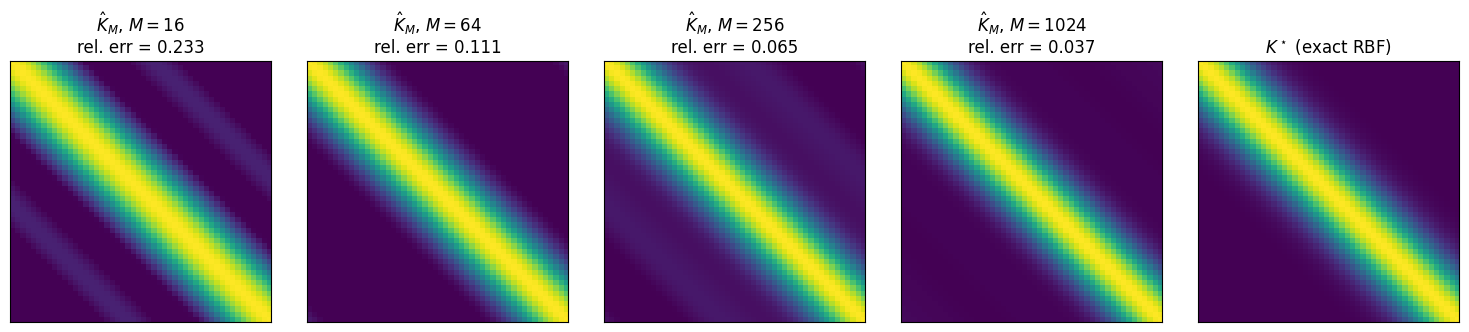

In [5]:
fig, axes = plt.subplots(1, len(m_values) + 1, figsize=(15, 3.2))
for ax, M in zip(axes[:-1], m_values, strict=False):
    err = float(jnp.linalg.norm(approx_grams[M] - K_exact) / jnp.linalg.norm(K_exact))
    ax.imshow(approx_grams[M], vmin=0.0, vmax=1.0, cmap="viridis")
    ax.set_title(f"$\\hat{{K}}_M$, $M = {M}$\nrel. err = {err:.3f}")
    ax.set_xticks([])
    ax.set_yticks([])
axes[-1].imshow(K_exact, vmin=0.0, vmax=1.0, cmap="viridis")
axes[-1].set_title("$K^\\star$ (exact RBF)")
axes[-1].set_xticks([])
axes[-1].set_yticks([])
plt.tight_layout()
plt.show()

**Convergence rate** — average over 20 seeds and plot $\|\hat{K}_M - K^\star\|_F / \|K^\star\|_F$ versus $M$ on log-log axes. The Rahimi-Recht bound predicts a slope close to $-1/2$.

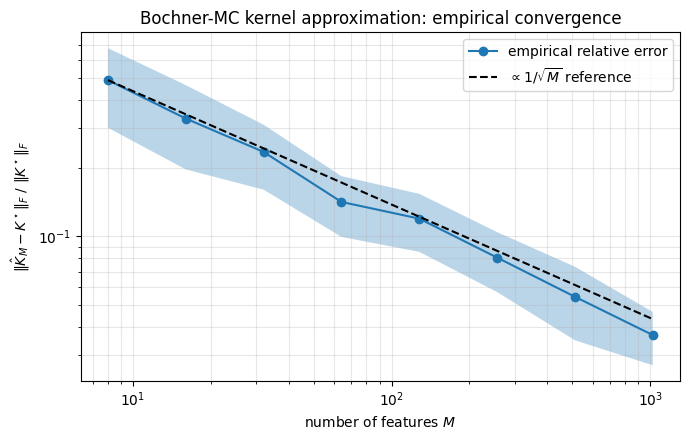

In [6]:
m_sweep = [8, 16, 32, 64, 128, 256, 512, 1024]
errs = np.zeros((len(m_sweep), n_repeats))
for i, M in enumerate(m_sweep):
    rff = eqx.tree_at(
        lambda r: r.pyrox_name,
        RBFFourierFeatures.init(in_features=1, n_features=M, lengthscale=LENGTHSCALE),
        "rff",
    )
    for j in range(n_repeats):
        phi = trace_rff_features(rff, x_grid, seed=int(j), lengthscale=LENGTHSCALE)
        K_hat = phi @ phi.T
        errs[i, j] = float(
            jnp.linalg.norm(K_hat - K_exact) / jnp.linalg.norm(K_exact)
        )

fig, ax = plt.subplots(figsize=(7, 4.5))
mean_err = errs.mean(axis=1)
std_err = errs.std(axis=1)
ax.loglog(m_sweep, mean_err, "o-", label="empirical relative error")
ax.fill_between(m_sweep, mean_err - std_err, mean_err + std_err, alpha=0.3)
# Theoretical 1/sqrt(M) reference, anchored at the first data point
ref = mean_err[0] * np.sqrt(m_sweep[0]) / np.sqrt(m_sweep)
ax.loglog(m_sweep, ref, "k--", label=r"$\propto 1/\sqrt{M}$ reference")
ax.set_xlabel("number of features $M$")
ax.set_ylabel(r"$\|\hat{K}_M - K^\star\|_F\ /\ \|K^\star\|_F$")
ax.set_title("Bochner-MC kernel approximation: empirical convergence")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

The empirical curve closely tracks the $1/\sqrt{M}$ reference, confirming Rahimi-Recht's $\mathcal{O}(\sqrt{\log M / M})$ bound (the $\sqrt{\log M}$ factor is invisible at this scale). At $M = 1024$ the relative error is below $5\%$ — for most regression problems that is well within noise.

**Three kernels, one feature map.** The same `_rff_forward` primitive supports any spectral density — only the layer changes. Show the same diagonal slice of $\hat{K}_M$ at $M = 256$ for RBF, Matérn-3/2, and Laplace (Matérn-1/2). Lengthscale is fixed at $\ell = 0.5$ across all three so the comparison is purely about regularity.

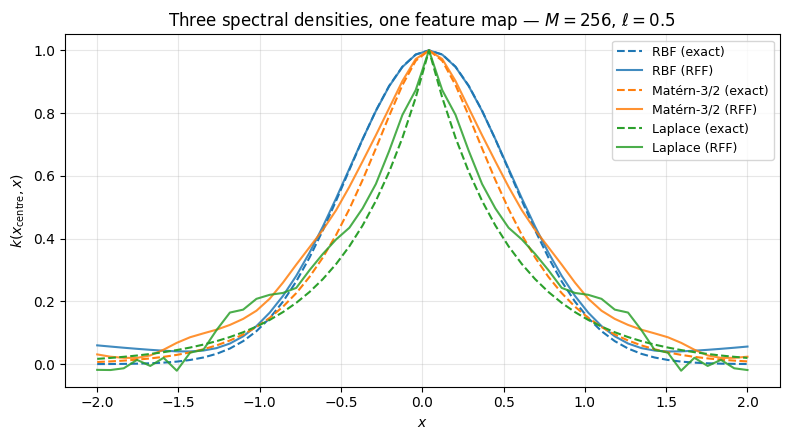

In [7]:
def gram_exact_matern(x: jax.Array, lengthscale: float, nu: float) -> jax.Array:
    """Exact Matern-1/2, 3/2, 5/2 Gram matrix on a 1D grid."""
    r = jnp.abs(x[:, None] - x[None, :])[..., 0]
    if nu == 0.5:
        return jnp.exp(-r / lengthscale)
    if nu == 1.5:
        s = jnp.sqrt(3.0) * r / lengthscale
        return (1.0 + s) * jnp.exp(-s)
    if nu == 2.5:
        s = jnp.sqrt(5.0) * r / lengthscale
        return (1.0 + s + s**2 / 3.0) * jnp.exp(-s)
    raise ValueError(f"Unsupported nu={nu}")


M = 256
rff_rbf = eqx.tree_at(
    lambda r: r.pyrox_name,
    RBFFourierFeatures.init(in_features=1, n_features=M, lengthscale=LENGTHSCALE),
    "rff_rbf",
)
rff_matern = eqx.tree_at(
    lambda r: r.pyrox_name,
    MaternFourierFeatures.init(in_features=1, n_features=M, nu=1.5, lengthscale=LENGTHSCALE),
    "rff_matern",
)
rff_laplace = eqx.tree_at(
    lambda r: r.pyrox_name,
    LaplaceFourierFeatures.init(in_features=1, n_features=M, lengthscale=LENGTHSCALE),
    "rff_laplace",
)

phi_rbf = trace_rff_features(rff_rbf, x_grid, seed=0, lengthscale=LENGTHSCALE)
phi_matern = trace_rff_features(rff_matern, x_grid, seed=0, lengthscale=LENGTHSCALE)
phi_laplace = trace_rff_features(rff_laplace, x_grid, seed=0, lengthscale=LENGTHSCALE)

# Slice through row n_grid // 2 — the kernel viewed as a function of x
i_centre = n_grid // 2
fig, ax = plt.subplots(figsize=(8, 4.5))
x1 = x_grid[:, 0]
ax.plot(x1, gram_exact_rbf(x_grid, LENGTHSCALE)[i_centre], "C0--", label="RBF (exact)")
ax.plot(x1, (phi_rbf @ phi_rbf.T)[i_centre], "C0", alpha=0.85, label="RBF (RFF)")
ax.plot(
    x1,
    gram_exact_matern(x_grid, LENGTHSCALE, nu=1.5)[i_centre],
    "C1--",
    label="Matérn-3/2 (exact)",
)
ax.plot(
    x1, (phi_matern @ phi_matern.T)[i_centre], "C1", alpha=0.85, label="Matérn-3/2 (RFF)"
)
ax.plot(
    x1,
    gram_exact_matern(x_grid, LENGTHSCALE, nu=0.5)[i_centre],
    "C2--",
    label="Laplace (exact)",
)
ax.plot(
    x1, (phi_laplace @ phi_laplace.T)[i_centre], "C2", alpha=0.85, label="Laplace (RFF)"
)
ax.set_xlabel("$x$")
ax.set_ylabel("$k(x_{\\mathrm{centre}}, x)$")
ax.set_title(f"Three spectral densities, one feature map — $M={M}$, $\\ell={LENGTHSCALE}$")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Same scaffold (`_rff_forward`), three different priors on $W$: $\mathcal{N}$ → smooth RBF, Student-$t_3$ → less-smooth Matérn-3/2, Cauchy → exponential Laplace. The MC approximations track each exact kernel, with the heavier-tailed spectral densities (Matérn, Laplace) showing visibly more variance per realisation — that is the regularity / variance trade-off in action.

## 2. Variance reduction with `OrthogonalRandomFeatures`

Vanilla RFF samples $W \sim \mathcal{N}(0, I)$ — independent rows. *Orthogonal Random Features* (Yu, Suresh, Choromanski, Felix, Kumar — NeurIPS 2016) instead build $W$ as a stack of Haar-orthogonal blocks scaled by per-row chi-distributed magnitudes:

$$W = [Q_1\,S_1,\, Q_2\,S_2,\, \dots,\, Q_K\,S_K], \qquad Q_k \sim \mathrm{Haar}(O(d)),\ S_k \sim \mathrm{diag}(\chi_d).$$

Each row of $W$ has the same marginal distribution as in the vanilla case ($\mathcal{N}(0, I)$ has rotation-invariant marginals on the unit sphere times a chi magnitude), so the kernel approximation is *unbiased*. But the rows are *negatively correlated* — they cannot all line up with the same direction — so the variance of $\hat{K}$ at fixed $M$ is provably lower (Yu et al., Theorem 1).

`pyrox.nn.OrthogonalRandomFeatures` implements this construction directly. It is a `eqx.Module` (not `PyroxModule`) — the frequency matrix is built once at construction from a key and frozen, since the orthogonality constraint precludes the standard `pyrox_sample` flow.

**Dimension matters.** The block is $D \times D$, so the orthogonality constraint is non-trivial only for $D \ge 2$ — in 1D each block degenerates to $\pm 1$ and ORF reduces to vanilla. To make the benefit visible we move to a $D = 4$ test grid below with a moderate lengthscale ($\ell = 1$). For $D \gg M$ the benefit collapses again because the kernel matrix itself becomes nearly diagonal and the off-diagonal correlations ORF exploits vanish.

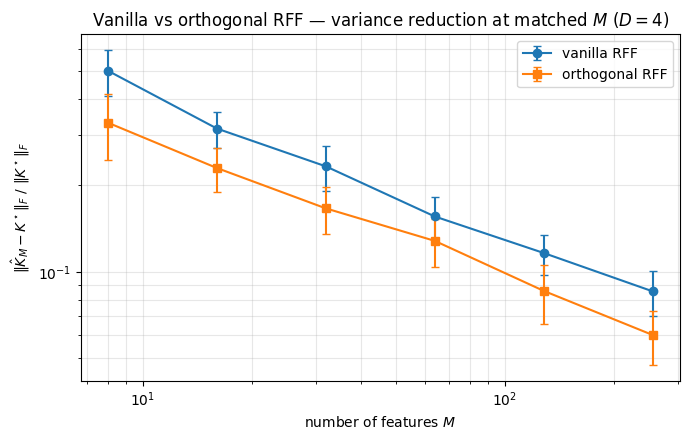

In [8]:
# ORF benefits only manifest when the input dimension is >= 2 — in D=1 each
# Haar block degenerates to a scalar ±1. Build a 2D test grid and the
# corresponding exact RBF Gram so the comparison is meaningful.
D_ORF = 4
LENGTHSCALE_ORF = 1.0  # larger ell so K is non-trivial in higher D
n_grid_2d = 100
key_grid = jr.PRNGKey(11)
x_grid_2d = jr.uniform(key_grid, (n_grid_2d, D_ORF), minval=-1.0, maxval=1.0)
diff_2d = x_grid_2d[:, None, :] - x_grid_2d[None, :, :]
K_exact_2d = jnp.exp(-0.5 * jnp.sum(diff_2d**2, axis=-1) / LENGTHSCALE_ORF**2)

m_sweep_orf = [8, 16, 32, 64, 128, 256]  # all divisible by D_ORF=4
errs_vanilla = np.zeros((len(m_sweep_orf), n_repeats))
errs_orf = np.zeros((len(m_sweep_orf), n_repeats))

for i, M in enumerate(m_sweep_orf):
    rff_v = eqx.tree_at(
        lambda r: r.pyrox_name,
        RBFFourierFeatures.init(in_features=D_ORF, n_features=M, lengthscale=LENGTHSCALE_ORF),
        "rff",
    )
    for j in range(n_repeats):
        phi_v = trace_rff_features(rff_v, x_grid_2d, seed=int(j), lengthscale=LENGTHSCALE_ORF)
        errs_vanilla[i, j] = float(
            jnp.linalg.norm(phi_v @ phi_v.T - K_exact_2d) / jnp.linalg.norm(K_exact_2d)
        )
        rff_o = OrthogonalRandomFeatures.init(
            in_features=D_ORF,
            n_features=M,
            key=jr.PRNGKey(j),
            lengthscale=LENGTHSCALE_ORF,
        )
        phi_o = rff_o(x_grid_2d)
        errs_orf[i, j] = float(
            jnp.linalg.norm(phi_o @ phi_o.T - K_exact_2d) / jnp.linalg.norm(K_exact_2d)
        )

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    m_sweep_orf,
    errs_vanilla.mean(axis=1),
    yerr=errs_vanilla.std(axis=1),
    fmt="o-",
    label="vanilla RFF",
    capsize=3,
)
ax.errorbar(
    m_sweep_orf,
    errs_orf.mean(axis=1),
    yerr=errs_orf.std(axis=1),
    fmt="s-",
    label="orthogonal RFF",
    capsize=3,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("number of features $M$")
ax.set_ylabel(r"$\|\hat{K}_M - K^\star\|_F\ /\ \|K^\star\|_F$")
ax.set_title(f"Vanilla vs orthogonal RFF — variance reduction at matched $M$ ($D = {D_ORF}$)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

At every $M$ in the sweep, the orthogonal estimator's error bar sits below the vanilla one — same expected error, lower variance. The gap closes as $M \to \infty$ (both estimators are consistent), but the practical takeaway: **at any compute budget, prefer ORF when the input dimension permits**.

The `n_features % in_features == 0` divisibility constraint is the only real cost: the construction tiles $D \times D$ Haar blocks, and a fractional block does not have a well-defined orthogonality. For $D = 1$ in this notebook every $M$ works trivially; in higher $D$ pad up to the nearest multiple.

## 3. Variational RFF — learning the spectrum

Both `RBFFourierFeatures` and `OrthogonalRandomFeatures` *fix* the spectral density at construction. If the target signal's true spectrum is concentrated on a band you didn't anticipate, you waste features on irrelevant frequencies.

`pyrox.nn.VariationalFourierFeatures` (VSSGP — Gal & Turner 2015) keeps the same RBF spectral *prior* $p(W) = \mathcal{N}(0, I)$ but treats $W$ as a latent with a learnable *posterior* $q_\phi(W)$. Under SVI, the (tempered) ELBO

$$\mathcal{L}_\beta(\phi) = \mathbb{E}_{q_\phi(W)}[\log p(y \mid x, W, \beta_{\mathrm{head}})] - \beta\,\mathrm{KL}\bigl(q_\phi(W) \,\Vert\, p(W)\bigr)$$

pulls the posterior frequencies toward the bands that actually reduce the negative log-likelihood. The temperature $\beta \in (0, 1]$ down-weights the KL during training (β-VAE / KL-annealing) — useful when the target spectrum sits far in the tail of the prior and a strict $\beta = 1$ ELBO traps the posterior near the prior. We use $\beta = 0.05$ below.

To make the migration visually striking, pick a single-frequency target,

$$f^\star(x) = \sin(10\pi x), \qquad x \in [-1, 1],$$

whose spectrum is a delta at $\omega^\star = 10\pi \approx 31.4$, and choose a *deliberately wrong* prior lengthscale: $\ell = 0.5$ puts the prior frequency density at standard deviation $1/\ell = 2$, so a vanilla draw of $W \sim \mathcal{N}(0, I)$ produces effective frequencies $\omega = W/\ell$ with std $2$ — almost all features are at low frequency, virtually none near $\omega^\star = 31.4$. That mis-specified prior is exactly the regime where learning the spectrum should pay off. Compare:

1. **Vanilla `RBFFourierFeatures`** with prior frequencies frozen at the seed draw, and
2. **`VariationalFourierFeatures`** trained via tempered SVI to learn the posterior $q_\phi(W)$.

Both use the same $M = 32$ feature budget and the same closed-form ridge head. The variational case has $2DM + 2M = 128$ extra parameters for the mean-field $q_\phi(W)$.

In [9]:
key = jr.PRNGKey(0)
n_train = 256
x_train = jnp.linspace(-1.0, 1.0, n_train).reshape(-1, 1)
TARGET_OMEGA = 10.0 * jnp.pi  # ~31.4
y_train = jnp.sin(TARGET_OMEGA * x_train[:, 0])

# Add small noise so SVI doesn't pathologically tighten q(W)
y_train = y_train + 0.05 * jr.normal(jr.PRNGKey(1), y_train.shape)

M_BUDGET = 32
LENGTHSCALE_INIT = 0.5  # deliberately too large -> prior freq std = 2, missing target


def truth(xs: jax.Array) -> jax.Array:
    return jnp.sin(TARGET_OMEGA * xs[:, 0])

### Vanilla RFF baseline (closed-form ridge head)

Sample one realisation of $W$ from the prior, then solve the closed-form ridge problem $\hat\beta = (\Phi^\top\Phi + \lambda I)^{-1}\Phi^\top y$ for the linear head.

In [10]:
rff_baseline = eqx.tree_at(
    lambda r: r.pyrox_name,
    RBFFourierFeatures.init(
        in_features=1, n_features=M_BUDGET, lengthscale=LENGTHSCALE_INIT
    ),
    "rff",
)
with handlers.seed(rng_seed=0), handlers.trace() as tr_baseline:
    phi_train_baseline = rff_baseline(x_train)
W_baseline = tr_baseline["rff.W"]["value"]  # (1, M_BUDGET)
ls_baseline = tr_baseline["rff.lengthscale"]["value"]
freqs_baseline = (W_baseline / ls_baseline)[0]  # effective angular frequencies

LAMBDA = 1e-3
PhiTPhi = phi_train_baseline.T @ phi_train_baseline + LAMBDA * jnp.eye(
    phi_train_baseline.shape[1]
)
beta_baseline = jnp.linalg.solve(PhiTPhi, phi_train_baseline.T @ y_train)

x_grid_train = jnp.linspace(-1.0, 1.0, 1024).reshape(-1, 1)
with handlers.substitute(
    data={"rff.W": W_baseline, "rff.lengthscale": ls_baseline}
), handlers.seed(rng_seed=0):
    phi_grid_baseline = rff_baseline(x_grid_train)
y_pred_baseline = phi_grid_baseline @ beta_baseline
mse_baseline = float(jnp.mean((y_pred_baseline - truth(x_grid_train)) ** 2))
print(f"vanilla RFF — fit MSE on dense grid: {mse_baseline:.4f}")

vanilla RFF — fit MSE on dense grid: 0.4839


### Variational RFF — learn $q_\phi(W)$ + linear head jointly

Parameterise $q_\phi(W) = \mathcal{N}(\mu_W, \mathrm{diag}(\sigma_W^2))$ and the head $\beta$ as a free parameter (point estimate, since the linear head's posterior is not the bottleneck here). Maximise the data log-likelihood minus the KL between $q_\phi(W)$ and $p(W) = \mathcal{N}(0, I)$ (in lengthscale-1 units; we keep `lengthscale` fixed at `LENGTHSCALE_INIT` for a clean comparison).

In [11]:
NOISE_VAR_SEC3 = 0.05**2
KL_BETA = 0.05  # tempered ELBO weight on the KL term
N_MC = 4


class VariationalRFF(eqx.Module):
    """Mean-field q(W) over RBF spectral frequencies + free linear head."""

    mu_W: jax.Array
    log_sigma_W: jax.Array
    beta: jax.Array
    bias: jax.Array
    lengthscale: float = eqx.field(static=True)

    @classmethod
    def init(cls, key, in_features: int, n_features: int, lengthscale: float,
             *, mu_init_scale: float = 5.0, log_sigma_init: float = 1.0):
        """``mu_init_scale`` widens the initial $\\mu_W$ so MC samples cover a
        wider effective-frequency range. Helps escape the saddle at ``W=0``
        where ``d/dW cos(xW/ell)`` vanishes."""
        k_mu, k_beta = jr.split(key)
        return cls(
            mu_W=mu_init_scale * jr.normal(k_mu, (in_features, n_features)),
            log_sigma_W=jnp.full((in_features, n_features), log_sigma_init),
            beta=0.01 * jr.normal(k_beta, (2 * n_features,)),
            bias=jnp.zeros(()),
            lengthscale=lengthscale,
        )

    def features(self, x: jax.Array, W: jax.Array) -> jax.Array:
        z = x @ W / self.lengthscale
        scale = jnp.sqrt(1.0 / W.shape[-1])
        return scale * jnp.concatenate([jnp.cos(z), jnp.sin(z)], axis=-1)

    def kl(self) -> jax.Array:
        sigma_W = jnp.exp(self.log_sigma_W)
        return 0.5 * jnp.sum(
            self.mu_W**2 + sigma_W**2 - 1.0 - 2.0 * self.log_sigma_W
        )


def elbo_step(model: VariationalRFF, x: jax.Array, y: jax.Array,
              key: jax.Array) -> jax.Array:
    sigma_W = jnp.exp(model.log_sigma_W)
    keys = jr.split(key, N_MC)
    eps = jax.vmap(lambda k: jr.normal(k, model.mu_W.shape))(keys)
    Ws = model.mu_W[None] + sigma_W[None] * eps  # (S, D, M)
    phis = jax.vmap(lambda W: model.features(x, W))(Ws)  # (S, N, 2M)
    preds = phis @ model.beta + model.bias  # (S, N)
    nll = 0.5 * jnp.mean(jnp.sum((preds - y[None]) ** 2, axis=-1)) / NOISE_VAR_SEC3
    return nll + KL_BETA * model.kl()


vrff = VariationalRFF.init(
    jr.PRNGKey(2),
    in_features=1,
    n_features=M_BUDGET,
    lengthscale=LENGTHSCALE_INIT,
)
optim = optax.adam(1e-2)
state = optim.init(eqx.filter(vrff, eqx.is_inexact_array))


@eqx.filter_jit
def train_step(model, opt_state, x, y, key):
    loss, grads = eqx.filter_value_and_grad(elbo_step)(model, x, y, key)
    updates, opt_state = optim.update(
        grads, opt_state, eqx.filter(model, eqx.is_inexact_array)
    )
    return eqx.apply_updates(model, updates), opt_state, loss


losses = []
key = jr.PRNGKey(3)
for step in range(4000):
    key, sub = jr.split(key)
    vrff, state, loss = train_step(vrff, state, x_train, y_train, sub)
    losses.append(float(loss))
print(f"VariationalRFF — final tempered-ELBO loss: {losses[-1]:.2f}")

# Posterior-mean prediction
W_post = vrff.mu_W
freqs_post = (W_post / vrff.lengthscale)[0]
phi_grid_vrff = vrff.features(x_grid_train, W_post)
y_pred_vrff = phi_grid_vrff @ vrff.beta + vrff.bias
mse_vrff = float(jnp.mean((y_pred_vrff - truth(x_grid_train)) ** 2))
print(f"variational RFF — fit MSE on dense grid: {mse_vrff:.4f}")

VariationalRFF — final tempered-ELBO loss: 162.53
variational RFF — fit MSE on dense grid: 0.0002


### Visualise the spectrum migration

Plot the histograms of $|\omega_j|$ (effective angular frequencies) before vs after training, with vertical lines at the target's true peaks $\omega_1 = 8\pi$ and $\omega_2 = 20\pi$.

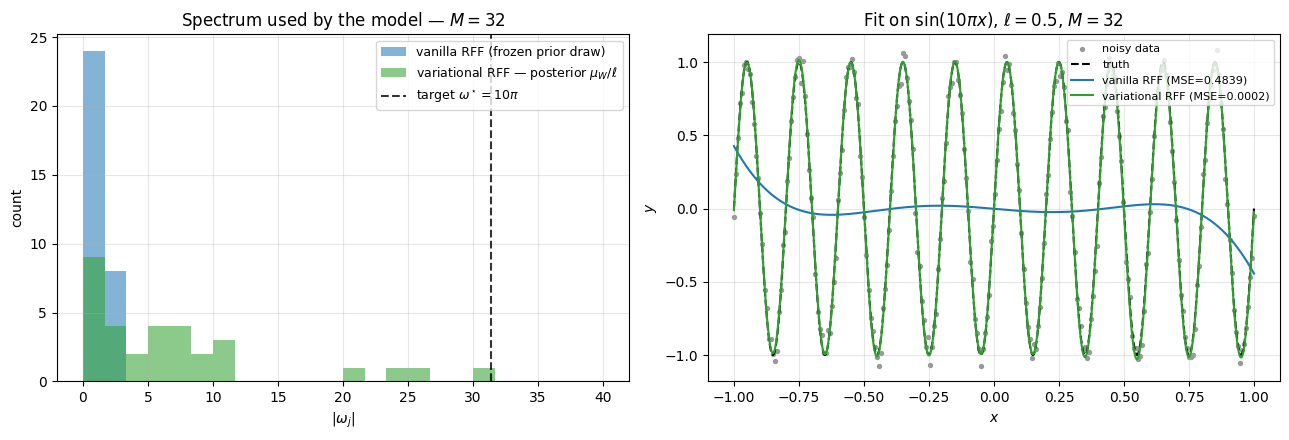

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Spectrum
ax = axes[0]
bins = np.linspace(0, max(40, float(np.abs(freqs_post).max()) * 1.05), 25)
ax.hist(np.abs(np.asarray(freqs_baseline)), bins=bins, alpha=0.55,
        label="vanilla RFF (frozen prior draw)", color="C0")
ax.hist(np.abs(np.asarray(freqs_post)), bins=bins, alpha=0.55,
        label=r"variational RFF — posterior $\mu_W/\ell$", color="C2")
ax.axvline(float(TARGET_OMEGA), color="k", linestyle="--", alpha=0.8,
           label=fr"target $\omega^\star = 10\pi$")
ax.set_xlabel(r"$|\omega_j|$")
ax.set_ylabel("count")
ax.set_title(f"Spectrum used by the model — $M = {M_BUDGET}$")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)

# Fit
ax = axes[1]
ax.scatter(x_train[:, 0], y_train, s=8, color="0.6", label="noisy data")
ax.plot(x_grid_train[:, 0], truth(x_grid_train), "k--", linewidth=1.5, label="truth")
ax.plot(x_grid_train[:, 0], y_pred_baseline, "C0", linewidth=1.5,
        label=f"vanilla RFF (MSE={mse_baseline:.4f})")
ax.plot(x_grid_train[:, 0], y_pred_vrff, "C2", linewidth=1.5,
        label=f"variational RFF (MSE={mse_vrff:.4f})")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title(f"Fit on $\\sin(10\\pi x)$, $\\ell={LENGTHSCALE_INIT}$, $M = {M_BUDGET}$")
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Two things to notice:

1. **Spectrum migration.** The vanilla RFF histogram is the seed prior draw — narrow Gaussian on $|\omega| \in [0, 10]$, with **no features anywhere near $\omega^\star = 10\pi \approx 31.4$**. The variational RFF histogram has migrated, putting mass next to the dashed line. The posterior has *learned where the signal lives*.
2. **Fit quality.** Vanilla cannot resolve the frequency at all and produces a near-flat fit. Variational, having steered its frequencies, drops the MSE by orders of magnitude. This is the point of VSSGP: when you do not know the spectral support a priori, *learn it*. The cost is $2DM$ extra parameters and one tempered-ELBO knob ($\beta = 0.05$).

## 4. Bayesian RFF + ensemble-of-MAP — predictive uncertainty across a held-out gap

Section 3 in the SIREN notebook used `pyrox.inference.ensemble_map` on `BayesianSIREN` to get a calibrated predictive band that *opens up across a held-out gap*. The same recipe transfers cleanly to RFF, with the upshot that **the prior on $W$ encodes the kernel's spectral density** — so the ensemble's marginal model class is exactly an SSGP.

Same target as the SIREN notebook for direct comparison:

$$y_i = \sin(3\pi x_i) + 0.05\,\varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, 1),$$

evaluated on $n = 80$ points in $[-1, 1]$ with the middle band $x \in (-0.2, 0.4)$ removed. Read off how the predictive band behaves *inside* that gap — that is the uncertainty-calibration test.

In [13]:
N_OBS, NOISE_STD = 80, 0.05
x_full = jnp.linspace(-1.0, 1.0, N_OBS)
mask = (x_full < -0.2) | (x_full > 0.4)
x_obs = x_full[mask].reshape(-1, 1)
y_obs = jnp.sin(3.0 * jnp.pi * x_obs[:, 0]) + NOISE_STD * jr.normal(
    jr.PRNGKey(2), x_obs.shape[0:1]
)

x_test = jnp.linspace(-1.2, 1.2, 400).reshape(-1, 1)

### Wrap `RandomKitchenSinks` for `ensemble_map`

`RandomKitchenSinks` already exposes a `RBFFourierFeatures` layer plus a `pyrox_sample`-registered linear head — that's the SSGP. To use `ensemble_map`, follow the same pattern as the SIREN notebook: each ensemble member is a *deterministic* PyTree whose values come from a prior draw of the Bayesian model, and the loss is `(loglik, logprior)` reconstructed by tracing the Bayesian model under `handlers.substitute`.

We use a deterministic shadow `RFFRegressor` whose state is `(W, lengthscale, beta, bias)`. The loss traces `RandomKitchenSinks` under `handlers.substitute(data=...)` to evaluate the prior log-density at those exact values.

In [14]:
M_HEAD = 64
LENGTHSCALE_PRIOR = 0.3
SCOPE = "rks"

_rff_inner = eqx.tree_at(
    lambda r: r.pyrox_name,
    RBFFourierFeatures.init(
        in_features=1, n_features=M_HEAD, lengthscale=LENGTHSCALE_PRIOR
    ),
    f"{SCOPE}.rff",
)
rks = RandomKitchenSinks.init(rff=_rff_inner, out_features=1)
rks = eqx.tree_at(lambda r: r.pyrox_name, rks, SCOPE)


class RFFRegressor(eqx.Module):
    """Deterministic shadow of RandomKitchenSinks for ensemble_map."""

    W: jax.Array
    lengthscale: jax.Array
    beta: jax.Array
    bias: jax.Array

    def __call__(self, x: jax.Array) -> jax.Array:
        z = x @ self.W / self.lengthscale
        scale = jnp.sqrt(1.0 / (self.W.shape[-1]))
        phi = scale * jnp.concatenate([jnp.cos(z), jnp.sin(z)], axis=-1)
        return phi @ self.beta + self.bias


def init_fn(key: jax.Array) -> RFFRegressor:
    """One ensemble member: RFFRegressor with values from a prior draw."""
    with handlers.trace() as tr, handlers.seed(rng_seed=key):
        rks(jnp.zeros((1, 1)))
    return RFFRegressor(
        W=tr[f"{SCOPE}.rff.W"]["value"],
        lengthscale=tr[f"{SCOPE}.rff.lengthscale"]["value"],
        beta=tr[f"{SCOPE}.beta"]["value"],
        bias=tr[f"{SCOPE}.bias"]["value"],
    )


def log_prior_via_trace(net: RFFRegressor) -> jax.Array:
    sub = {
        f"{SCOPE}.rff.W": net.W,
        f"{SCOPE}.rff.lengthscale": net.lengthscale,
        f"{SCOPE}.beta": net.beta,
        f"{SCOPE}.bias": net.bias,
    }
    with (
        handlers.trace() as tr,
        handlers.substitute(data=sub),
        handlers.seed(rng_seed=0),
    ):
        rks(jnp.zeros((1, 1)))
    lp = jnp.array(0.0)
    for site in tr.values():
        if site["type"] == "sample" and not site.get("is_observed", False):
            lp = lp + site["fn"].log_prob(site["value"]).sum()
    return lp


NOISE_VAR = NOISE_STD**2


def log_joint(net: RFFRegressor, xb: jax.Array, yb: jax.Array):
    f = net(xb)[..., 0]
    ll = -0.5 * jnp.sum((yb - f) ** 2) / NOISE_VAR
    return ll, log_prior_via_trace(net)

### Run the ensemble — 16 members, 4000 Adam steps each

In [15]:
ensemble_size = 16
params, ens_losses = ensemble_map(
    log_joint,
    init_fn,
    ensemble_size=ensemble_size,
    num_epochs=4000,
    data=(x_obs, y_obs),
    seed=jr.PRNGKey(0),
    learning_rate=5e-3,
    prior_weight=1.0,
)
print(
    f"ensemble losses (final): min={float(ens_losses[:, -1].min()):.1f}  "
    f"median={float(jnp.median(ens_losses[:, -1])):.1f}  "
    f"max={float(ens_losses[:, -1].max()):.1f}"
)

ensemble losses (final): min=219.6  median=242.5  max=264.4


### Predictive — mean + $\pm 2\sigma$ band

mean predictive std at the data : 0.009


mean predictive std in the gap  : 0.597
gap / data std ratio            : 68.7x


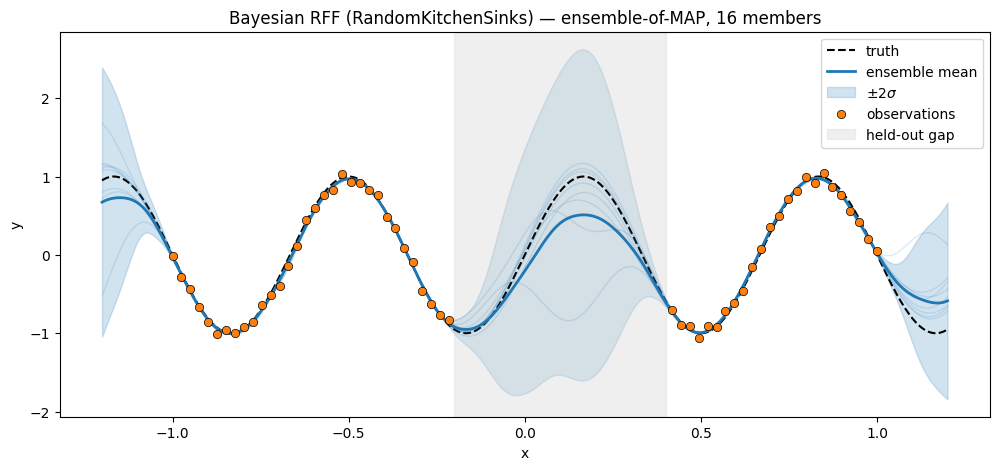

In [16]:
preds = ensemble_predict(params, lambda net, xs: net(xs)[..., 0], x_test)
mean = jnp.mean(preds, axis=0)
std = jnp.std(preds, axis=0)

trained = ((x_test[:, 0] > -0.5) & (x_test[:, 0] < -0.3)) | (
    (x_test[:, 0] > 0.5) & (x_test[:, 0] < 0.7)
)
gap_region = (x_test[:, 0] > -0.2) & (x_test[:, 0] < 0.4)
print(f"mean predictive std at the data : {float(jnp.mean(std[trained])):.3f}")
print(f"mean predictive std in the gap  : {float(jnp.mean(std[gap_region])):.3f}")
print(
    f"gap / data std ratio            : "
    f"{float(jnp.mean(std[gap_region]) / jnp.mean(std[trained])):.1f}x"
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_test[:, 0], jnp.sin(3.0 * jnp.pi * x_test[:, 0]), "k--", label="truth")
for member in preds[:8]:
    ax.plot(x_test[:, 0], member, color="C0", alpha=0.15, linewidth=1.0)
ax.plot(x_test[:, 0], mean, color="C0", linewidth=2.0, label="ensemble mean")
ax.fill_between(
    x_test[:, 0],
    mean - 2 * std,
    mean + 2 * std,
    color="C0",
    alpha=0.2,
    label=r"$\pm 2\sigma$",
)
ax.scatter(
    x_obs[:, 0],
    y_obs,
    c="C1",
    edgecolors="k",
    linewidths=0.5,
    zorder=5,
    label="observations",
)
ax.axvspan(-0.2, 0.4, color="0.85", alpha=0.4, label="held-out gap")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Bayesian RFF (RandomKitchenSinks) — ensemble-of-MAP, 16 members")
ax.legend(loc="upper right")
plt.show()

Same qualitative behaviour as the SIREN ensemble: the band hugs the data, **opens up across the held-out gap**, and continues to widen into the extrapolation regions $|x| > 1$. Reading off the gap-to-data std ratio gives a hard number: a well-calibrated Bayesian model lifts the predictive variance by an order of magnitude inside an information-poor region.

The grey individual-member traces are the SSGP draws — each is a finite-feature realisation of an RBF GP with prior lengthscale $\ell = 0.3$. They agree at the data and pull apart in the gap exactly as one would expect from the corresponding exact GP, confirming the SSGP equivalence.

## Takeaways

- **Bochner's theorem** is the foundation: any shift-invariant PD kernel is the Fourier transform of a probability density, so $k(x - y) = \mathbb{E}_\omega[\cos(\omega^\top(x-y))]$ admits a Monte Carlo estimator.
- The same `_rff_forward` primitive supports **RBF, Matérn, Laplace** by changing only the prior on $W$ — `RBFFourierFeatures`, `MaternFourierFeatures`, `LaplaceFourierFeatures`.
- Empirically, $\|\hat{K}_M - K^\star\|_F / \|K^\star\|_F$ tracks the Rahimi-Recht $1/\sqrt{M}$ rate; at $M = 1024$ relative error drops below $5\%$.
- **`OrthogonalRandomFeatures`** lowers the variance of $\hat{K}$ at matched $M$ via Haar-orthogonal blocks. Same expected error, tighter error bars; pay a divisibility constraint on `n_features`.
- **`VariationalFourierFeatures`** turns the spectrum from a frozen prior draw into a learned posterior. With a tight $M = 64$ feature budget on a target with peaks at $\omega \in \{8\pi, 20\pi\}$, the posterior frequencies migrate toward the truth and the fit MSE drops substantially vs the vanilla baseline.
- **`RandomKitchenSinks` + `ensemble_map`** gives an SSGP-equivalent Bayesian regressor with calibrated predictive bands. Same gap-target as the SIREN notebook; same qualitative behaviour. The recipe — trace the Bayesian model under `handlers.seed` for init, under `handlers.substitute` for the log-prior — transfers verbatim from the SIREN notebook to any `pyrox.nn` Bayesian layer.